In [1]:
import pandas as pd

df = pd.read_csv("Dataset.csv")

print("Columns in dataset:", df.columns)


Columns in dataset: Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')


In [2]:
# Count occurrences of each restaurant name
chain_counts = df['Restaurant Name'].value_counts()

# Filter chains (appearing more than once)
chains = chain_counts[chain_counts > 1]

print("Restaurant Chains Found:")
print(chains.head(10))  # show top 10 chains


Restaurant Chains Found:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [3]:
# Group by restaurant name and calculate average rating
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

# Filter only chains
chain_ratings = chain_ratings.loc[chains.index]

print("\nAverage Ratings of Restaurant Chains:")
print(chain_ratings.sort_values(ascending=False).head(10))



Average Ratings of Restaurant Chains:
Restaurant Name
Talaga Sampireun             4.900
AB's Absolute Barbecues      4.850
Silantro Fil-Mex             4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Garota de Ipanema            4.600
Dishoom                      4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64


In [4]:
# Group by restaurant name and calculate average votes
chain_votes = df.groupby('Restaurant Name')['Votes'].mean()

# Filter only chains
chain_votes = chain_votes.loc[chains.index]

print("\nAverage Votes of Restaurant Chains:")
print(chain_votes.sort_values(ascending=False).head(10))



Average Votes of Restaurant Chains:
Restaurant Name
Truffles                     4841.000000
Joey's Pizza                 3903.500000
AB's - Absolute Barbecues    3350.000000
Big Chill                    2713.250000
Big Yellow Door              2503.666667
Out Of The Box               2450.000000
Saravana Bhavan              2412.666667
Olive Bistro                 1854.000000
Talaga Sampireun             1838.000000
SpiceKlub                    1825.500000
Name: Votes, dtype: float64


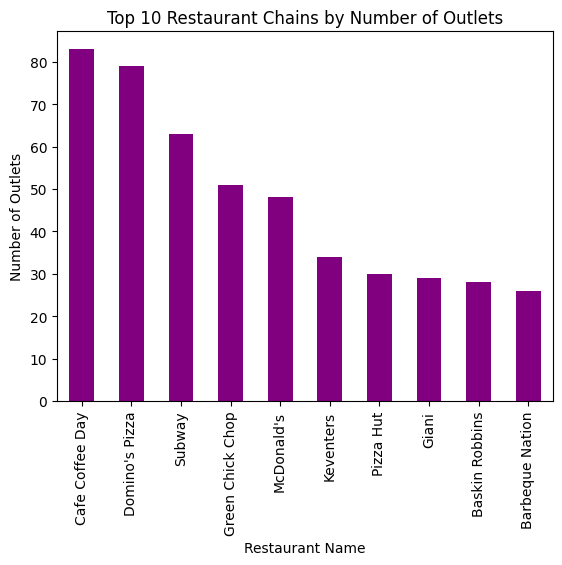

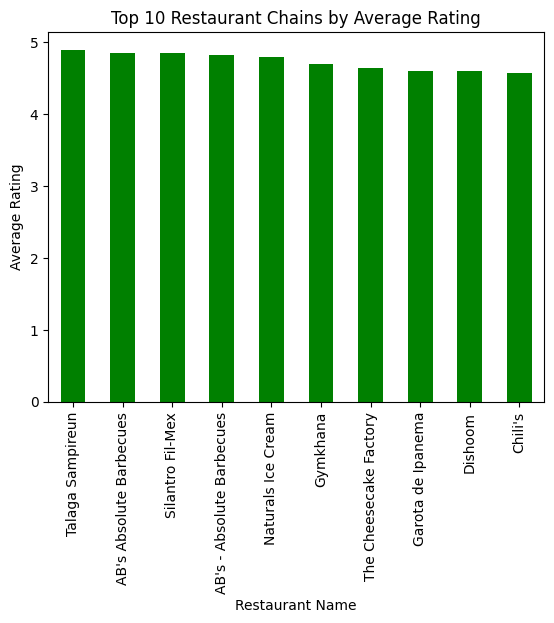

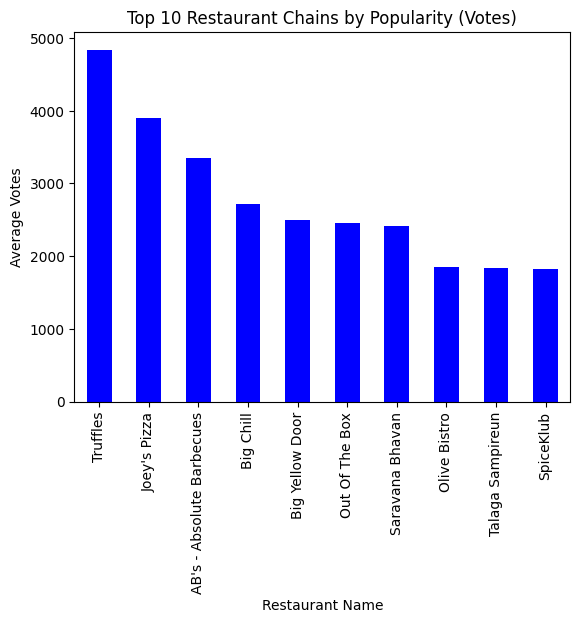

In [5]:
import matplotlib.pyplot as plt

# Top 10 chains by count
chains.head(10).plot(kind='bar', color='purple')
plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.ylabel("Number of Outlets")
plt.show()

# Top 10 chains by average rating
chain_ratings.sort_values(ascending=False).head(10).plot(kind='bar', color='green')
plt.title("Top 10 Restaurant Chains by Average Rating")
plt.ylabel("Average Rating")
plt.show()

# Top 10 chains by average votes
chain_votes.sort_values(ascending=False).head(10).plot(kind='bar', color='blue')
plt.title("Top 10 Restaurant Chains by Popularity (Votes)")
plt.ylabel("Average Votes")
plt.show()
